<a href="https://colab.research.google.com/github/mohamadatashfaraz4-netizen/master-thesis/blob/main/9_Robustheitsexperiment_mit_kuenstlichen_Datenfehlern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q tabpfn scikit-learn pandas numpy matplotlib openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.6/745.6 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
import os
from getpass import getpass

os.environ["TABPFN_TOKEN"] = getpass("Geben Sie Ihr TABPFN-Token ein: ")

Geben Sie Ihr TABPFN-Token ein: ··········


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
from tabpfn import TabPFNClassifier
from google.colab import files

In [4]:
def evaluate_classifier(model, x_eval, y_eval):
    """Genauigkeit, ROC-AUC, Vorhersagen und Wahrscheinlichkeiten der positiven Klasse zurückgeben."""
    predictions = model.predict(x_eval)
    probabilities = model.predict_proba(x_eval)[:, 1]

    metrics = {
        "accuracy": float(accuracy_score(y_eval, predictions)),
        "roc_auc": float(roc_auc_score(y_eval, probabilities)),
    }

    return metrics, predictions, probabilities


def inject_missing_values(x, rate, rng):
    """Fehlende Werte zellenweise einfügen."""
    corrupted = x.copy().astype(float)
    mask = rng.random(corrupted.shape) < rate
    corrupted[mask] = np.nan
    row_labels = mask.any(axis=1).astype(int)
    return corrupted, row_labels


def inject_outliers(x, rate, rng, factor=8.0):
    """Zeilenweise numerische Ausreißer durch Skalierung ausgewählter Zeilen einfügen."""
    corrupted = x.copy().astype(float)
    count = max(1, int(rate * corrupted.shape[0])) if rate > 0 else 0
    row_labels = np.zeros(corrupted.shape[0], dtype=int)

    if count:
        indices = rng.choice(corrupted.shape[0], size=count, replace=False)
        corrupted[indices] *= factor
        row_labels[indices] = 1

    return corrupted, row_labels


def inject_label_noise(y, rate, rng):
    """Binäre Trainingslabels umkehren."""
    corrupted = y.copy()
    count = max(1, int(rate * len(corrupted))) if rate > 0 else 0

    if count:
        indices = rng.choice(len(corrupted), size=count, replace=False)
        corrupted[indices] = 1 - corrupted[indices]

    return corrupted


def inject_feature_noise(x, rate, rng, noise_scale=0.35):
    """Gaußsches Rauschen zu einer Teilmenge der Zeilen und allen numerischen Merkmalen hinzufügen."""
    corrupted = x.copy().astype(float)
    count = max(1, int(rate * corrupted.shape[0])) if rate > 0 else 0
    row_labels = np.zeros(corrupted.shape[0], dtype=int)

    if count:
        indices = rng.choice(corrupted.shape[0], size=count, replace=False)

        feature_std = np.nanstd(corrupted, axis=0)
        feature_std[feature_std == 0] = 1.0

        noise = rng.normal(
            loc=0.0,
            scale=noise_scale * feature_std,
            size=(count, corrupted.shape[1]),
        )

        corrupted[indices] = corrupted[indices] + noise
        row_labels[indices] = 1

    return corrupted, row_labels


def uncertainty_detection(probabilities, row_labels):
    """"Das obere Quartil der Unsicherheit als einfache Markierungsheuristik verwenden."""
    uncertainty = 1 - np.maximum(probabilities, 1 - probabilities)
    threshold = float(np.quantile(uncertainty, 0.75))
    flags = (uncertainty >= threshold).astype(int)

    return {
        "precision": float(precision_score(row_labels, flags, zero_division=0)),
        "recall": float(recall_score(row_labels, flags, zero_division=0)),
        "f1": float(f1_score(row_labels, flags, zero_division=0)),
        "threshold": threshold,
    }

In [5]:
rng = np.random.default_rng(2026)

# Sauberen und bekannten Referenzdatensatz laden
x, y = load_breast_cancer(return_X_y=True)

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y,
)

# TabPFN mit sauberen Trainingsdaten trainieren
clean_model = TabPFNClassifier()
clean_model.fit(x_train, y_train)

clean_metrics, _, clean_probabilities = evaluate_classifier(
    clean_model,
    x_test,
    y_test,
)

clean_confidence = float(
    np.mean(np.maximum(clean_probabilities, 1 - clean_probabilities))
)

levels = [0.00, 0.05, 0.10, 0.20, 0.30]
rows = []

rows.append({
    "error_type": "clean_reference",
    "level": 0.0,
    "accuracy": clean_metrics["accuracy"],
    "roc_auc": clean_metrics["roc_auc"],
    "accuracy_drop": 0.0,
    "roc_auc_drop": 0.0,
    "mean_confidence": clean_confidence,
    "uncertainty_f1": np.nan,
})

for level in levels:
       # Fehlende Werte in den Testdaten
    x_missing, missing_rows = inject_missing_values(x_test, level, rng)
    metrics, _, probabilities = evaluate_classifier(clean_model, x_missing, y_test)
    detection = uncertainty_detection(probabilities, missing_rows) if level > 0 else {"f1": np.nan}

    rows.append({
        "error_type": "missing_values",
        "level": level,
        "accuracy": metrics["accuracy"],
        "roc_auc": metrics["roc_auc"],
        "accuracy_drop": clean_metrics["accuracy"] - metrics["accuracy"],
        "roc_auc_drop": clean_metrics["roc_auc"] - metrics["roc_auc"],
        "mean_confidence": float(np.mean(np.maximum(probabilities, 1 - probabilities))),
        "uncertainty_f1": detection["f1"],
    })

     # Ausreißer in den Testdaten
    x_outliers, outlier_rows = inject_outliers(x_test, level, rng, factor=8.0)
    metrics, _, probabilities = evaluate_classifier(clean_model, x_outliers, y_test)
    detection = uncertainty_detection(probabilities, outlier_rows) if level > 0 else {"f1": np.nan}

    rows.append({
        "error_type": "outliers",
        "level": level,
        "accuracy": metrics["accuracy"],
        "roc_auc": metrics["roc_auc"],
        "accuracy_drop": clean_metrics["accuracy"] - metrics["accuracy"],
        "roc_auc_drop": clean_metrics["roc_auc"] - metrics["roc_auc"],
        "mean_confidence": float(np.mean(np.maximum(probabilities, 1 - probabilities))),
        "uncertainty_f1": detection["f1"],
    })

      # Merkmalsrauschen in den Testdaten
    x_feature_noise, noisy_rows = inject_feature_noise(x_test, level, rng)
    metrics, _, probabilities = evaluate_classifier(clean_model, x_feature_noise, y_test)
    detection = uncertainty_detection(probabilities, noisy_rows) if level > 0 else {"f1": np.nan}

    rows.append({
        "error_type": "feature_noise",
        "level": level,
        "accuracy": metrics["accuracy"],
        "roc_auc": metrics["roc_auc"],
        "accuracy_drop": clean_metrics["accuracy"] - metrics["accuracy"],
        "roc_auc_drop": clean_metrics["roc_auc"] - metrics["roc_auc"],
        "mean_confidence": float(np.mean(np.maximum(probabilities, 1 - probabilities))),
        "uncertainty_f1": detection["f1"],
    })

    # Falsche Labels in den Trainingsdaten
    noisy_y_train = inject_label_noise(y_train, level, rng)

    noisy_label_model = TabPFNClassifier()
    noisy_label_model.fit(x_train, noisy_y_train)

    metrics, _, probabilities = evaluate_classifier(
        noisy_label_model,
        x_test,
        y_test,
    )

    rows.append({
        "error_type": "wrong_labels",
        "level": level,
        "accuracy": metrics["accuracy"],
        "roc_auc": metrics["roc_auc"],
        "accuracy_drop": clean_metrics["accuracy"] - metrics["accuracy"],
        "roc_auc_drop": clean_metrics["roc_auc"] - metrics["roc_auc"],
        "mean_confidence": float(np.mean(np.maximum(probabilities, 1 - probabilities))),
        "uncertainty_f1": np.nan,
    })

robustness_df = pd.DataFrame(rows)
robustness_df

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

,error_type,level,accuracy,roc_auc,accuracy_drop,roc_auc_drop,mean_confidence,uncertainty_f1
0,clean_reference,0.00,0.968085,0.997942,0.000000,0.000000e+00,0.964538,NaN
1,missing_values,0.00,0.968085,0.997942,0.000000,0.000000e+00,0.964538,NaN
2,outliers,0.00,0.968085,0.997942,0.000000,0.000000e+00,0.964538,NaN
3,feature_noise,0.00,0.968085,0.997942,0.000000,0.000000e+00,0.964538,NaN
4,wrong_labels,0.00,0.968085,0.997942,0.000000,0.000000e+00,0.964538,NaN
5,missing_values,0.05,0.968085,0.998305,0.000000,-3.631961e-04,0.960891,0.412371
6,outliers,0.05,0.941489,0.985472,0.026596,1.246973e-02,0.966913,0.000000
7,feature_noise,0.05,0.968085,0.997942,0.000000,-1.110223e-16,0.961864,0.285714
8,wrong_labels,0.05,0.973404,0.997579,-0.005319,3.631961e-04,0.939862,NaN
9,missing_values,0.10,0.973404,0.998426,-0.005319,-4.842615e-04,0.954456,0.412556


In [6]:
csv_name = "chapter09-robustness_experiment.csv"
xlsx_name = "chapter09-robustness_experiment.xlsx"

robustness_df.to_csv(csv_name, index=False, encoding="utf-8-sig")
robustness_df.to_excel(xlsx_name, index=False)

files.download(csv_name)
files.download(xlsx_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

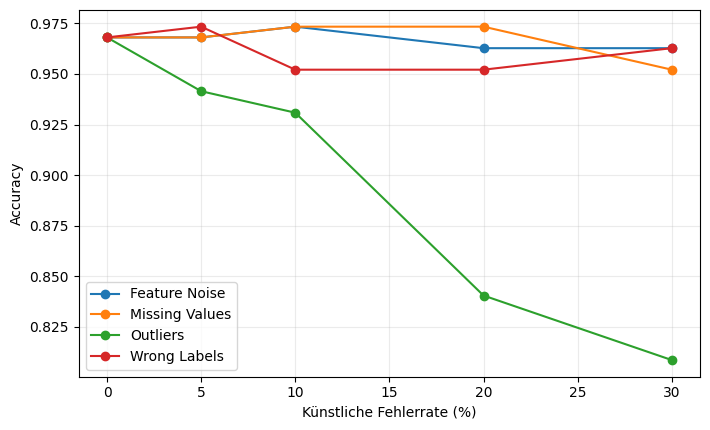

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

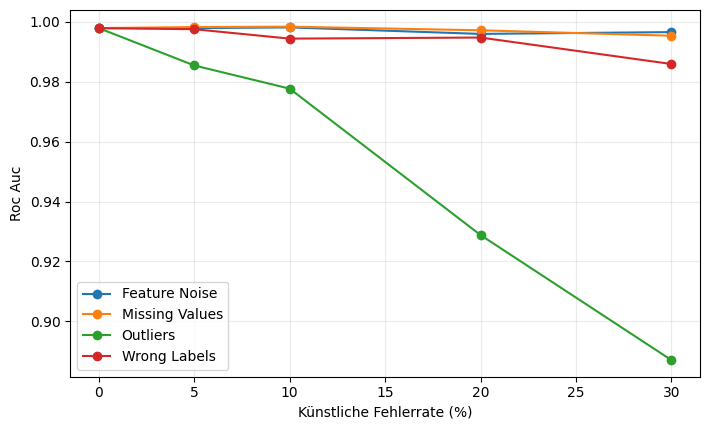

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

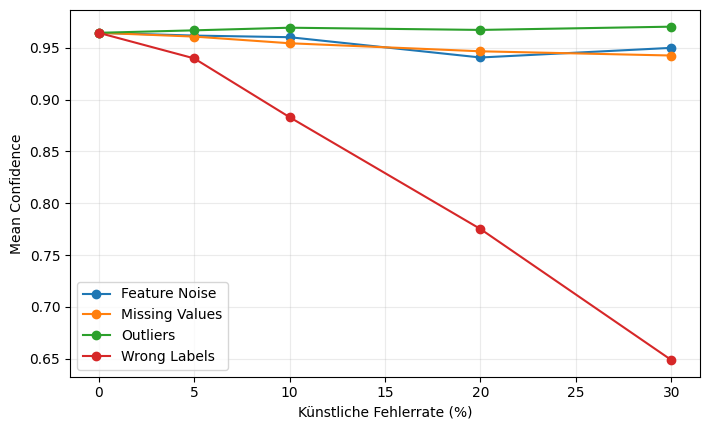

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
label_map = {
    "missing_values": "Missing Values",
    "outliers": "Outliers",
    "wrong_labels": "Wrong Labels",
    "feature_noise": "Feature Noise",
}

plot_df = robustness_df[robustness_df["error_type"] != "clean_reference"].copy()

for metric in ["accuracy", "roc_auc", "mean_confidence"]:
    plt.figure(figsize=(7.2, 4.4))

    for error_type, part in plot_df.groupby("error_type"):
        plt.plot(
            part["level"] * 100,
            part[metric],
            marker="o",
            label=label_map.get(error_type, error_type),
        )

    plt.xlabel("Künstliche Fehlerrate (%)")
    plt.ylabel(metric.replace("_", " ").title())
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()

    file_name = f"chapter09-robustness_{metric}.png"
    plt.savefig(file_name, dpi=180)
    plt.show()

    files.download(file_name)

In [14]:
from google.colab import _message
import json

nb = _message.blocking_request("get_ipynb")["ipynb"]

nb.setdefault("metadata", {}).pop("widgets", None)

out = "/content/clean_notebook.ipynb"
with open(out, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print(out)

/content/clean_notebook.ipynb
